#**📈Timeseries and Heatmap Visualization for Extreme Events**

> **Updated** 26-Dec-2025 <br/>
> **Team** ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)<br/>
> **Contact** Miae Kim (miaekim@apcc21.org)
<br/>

In this notebook, you will display timeseries of extreme phenomena such as anomalously high temperatures(AHT), heavy rainfall(HR), and marine heatwaves(MHW) for a specific grid point in East Asia.

Data Directory: 0.ExtremeEvents_ERA5_OISST, 1.Daily_ERA5_OISST

## ⚙️**Requirements**

***"You can mount /content/drive/ to your Google Drive, where you will download data from the GitHub page(https://github.com/yyalexlee/EastAsiaClimateExtremes/tree/main)."***

In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Download data**

Create FIRST directories if needed with the following line OR by yourself.

You can change the following path.

In [113]:
#!mkdir -p /content/drive/MyDrive/APCC/Data/

Refer to the GitHub page for downloading data.

In [114]:
#!wget -O /content/drive/MyDrive/APCC/Data/0.ExtremeEvents_ERA5_OISST.zip "https://www.dropbox.com/scl/fo/5hcy3r8jxd6o9qaa267bf/AMI0pTgTvZWf1MXq7SgAZwk?rlkey=z3x1kyrynjeg0wctprfk31aj1&st=ryo0cv1h&dl=0"

In [115]:
#!wget -O /content/drive/MyDrive/APCC/Data/1.Daily_ERA5_OISST.zip "https://www.dropbox.com/scl/fo/t8082lha97fi5ebqsq77x/ACZu-o6b-b4e05S81-7BkQs?rlkey=d5v7ztkp71nb4d7jx19pgv97u&st=9h8y9v6x&dl=0"

Run the following line to unzip the data OR unzip by yourself.

In [116]:
#!unzip '/content/drive/MyDrive/APCC/Data/0.ExtremeEvents_ERA5_OISST.zip' -d '/content/drive/MyDrive/APCC/Data/0.ExtremeEvents_ERA5_OISST/'

In [117]:
#!unzip '/content/drive/MyDrive/APCC/Data/1.Daily_ERA5_OISST.zip' -d '/content/drive/MyDrive/APCC/Data/1.Daily_ERA5_OISST/'

✅ Delete the zip files to save space.

### **Import libraries**

In [118]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from matplotlib.gridspec import GridSpec
import os
import matplotlib.ticker as mtick
from scipy import stats
import seaborn as sns
from scipy.stats import linregress
from pprint import pprint
from pathlib import Path

### **Set paths**

CHANGE the following paths if needed!

In [119]:
PATH_data1 = "/content/drive/MyDrive/APCC/Data/0.ExtremeEvents_ERA5_OISST/"
PATH_data2 = "/content/drive/MyDrive/APCC/Data/1.Daily_ERA5_OISST/"
PATH_save_fig = "/content/drive/MyDrive/APCC/figures/"
PATH_save_stat = "/content/drive/MyDrive/APCC/statistics/"

In [120]:
Path(PATH_save_fig).mkdir(parents=True, exist_ok=True)

### **Set options**

***"You CAN change the target variable, the coordinates, and the start and end dates BELOW."***

In [121]:
# === Set options
thr = '90'
ref_syear, ref_eyear = 1991, 2020
target_date_start, target_date_end = '2024-01-01', '2024-12-31'
target_year_start, target_year_end = '1940', '2024'

# --- Heavy rainfall(HR)
# varname0 = 'HR'
# crt = 'D1G3' # _D1G3, _D3G3
# lat_oi, lon_oi = 36.235774, 127.371063 # Over land

# --- High temperatures(AHT)
# varname0 = 'AHT'
# crt = 'D3G5' # _D5G2, _D3G5
# lat_oi, lon_oi = 36.235774, 127.371063 # Over land

# --- Marine heatwaves(MHW)
varname0 = 'MHW'
crt = 'D5G2' # _D5G2, _D3G5
lat_oi, lon_oi = 35.076912, 129.869889 # Over ocean for MHW

### **Load data**

In [122]:
# === Load event and raw data
if varname0 == 'HR':
    with open(os.path.join(PATH_data1, 'event.HR.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data1 = pickle.load(file)
    with open(os.path.join(PATH_data2, f'daily.TP.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data2 = pickle.load(file)
elif varname0 == 'AHT':
    with open(os.path.join(PATH_data1, 'event.AHT.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data1 = pickle.load(file)
    with open(os.path.join(PATH_data2, f'daily.T2M.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data2 = pickle.load(file)
elif varname0 == 'MHW':
    with open(os.path.join(PATH_data1, 'event.MHW.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data1 = pickle.load(file)
    with open(os.path.join(PATH_data2, f'daily.SST.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data2 = pickle.load(file)

print(data1.keys())
print(data2.keys())

/tmp/ipykernel_2566/4072593746.py:14: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data1 = pickle.load(file)
/tmp/ipykernel_2566/4072593746.py:16: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case,

dict_keys(['lat', 'lon', 'dates', 'dates_YM', 'event90_D5G2', 'event90_D3G5', 'event95_D5G2', 'event95_D3G5', 'ImF90_moving7d', 'EDays90_moving7d', 'IntMx90_moving7d', 'ImF95_moving7d', 'EDays95_moving7d', 'IntMx95_moving7d', 'ImF90_mon', 'EDays90_mon', 'IntMx90_mon', 'ImF95_mon', 'EDays95_mon', 'IntMx95_mon'])
dict_keys(['sst', 'lat', 'lon', 'dates', 'dates_YM', 'clim', 'thresh90', 'thresh95'])


In [123]:
# === Assign variables
lat, lon  = data1['lat'], data1['lon']
dates = data1['dates']
print('lat lon shapes:', lat.shape, lon.shape)

lat lon shapes: (19,) (19,)


In [124]:
varname = next(iter(data2))
values = data2[varname]
print('varname:', varname)
print('values shape:', values.shape)

varname: sst
values shape: (31047, 19, 19)


In [125]:
thresh = data2[f'thresh{thr}']
clim = data2['clim']
events = data1[f'event{thr}_{crt}']
print(f'event{thr}_{crt}:\n', events.keys())

event90_D5G2:
 dict_keys(['time_start', 'time_end', 'time_peak', 'date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration', 'duration_moderate', 'duration_strong', 'duration_severe', 'duration_extreme', 'intensity_max', 'intensity_mean', 'intensity_var', 'intensity_cumulative', 'intensity_max_relThresh', 'intensity_mean_relThresh', 'intensity_var_relThresh', 'intensity_cumulative_relThresh', 'intensity_max_abs', 'intensity_mean_abs', 'intensity_var_abs', 'intensity_cumulative_abs', 'category', 'rate_onset', 'rate_decline', 'n_events'])


### **Select closest grid point**

In [126]:
# === grid point of interest
ly = lat[np.abs(lat - lat_oi).argmin()]
lx = lon[np.abs(lon - lon_oi).argmin()]
print('closest lat and lon:', ly, lx)
ly_,lx_ = str(ly)+'N',str(lx)+'E'
iy, ix = np.argwhere(lat==ly)[0][0], np.argwhere(lon==lx)[0][0]

closest lat and lon: 34.5 130.5


### **Create binary event array**

In [127]:
# === Create binary event array using index_start and index_end
# Initialize array
event_binary = np.zeros(len(dates), dtype=int)

# Get the start and end indices of the event at the specific grid point
start_indices = events['index_start'][ly_, lx_]  # event start indices
end_indices = events['index_end'][ly_, lx_]      # event end indices

# Set the range from start_idx to end_idx (inclusive) to 1
for start_idx, end_idx in zip(start_indices, end_indices):
    event_binary[start_idx:end_idx+1] = 1

print(f"Total data size: {event_binary.shape[0]}")
print(f"Total event days: {np.sum(event_binary)}")
print(f"Percentage of event days: {np.sum(event_binary)/len(event_binary)*100:.2f}%")

Total data size: 31047
Total event days: 2041
Percentage of event days: 6.57%


### **Prepare dataframe for plotting**

In [128]:
values_pt = values[:,iy,ix]
thresh_pt = np.array(thresh[ly_,lx_])
clim_pt = np.array(clim[ly_,lx_])
df = pd.DataFrame({'date':dates, 'value':values_pt, 'thresh':thresh_pt, 'clim':clim_pt, 'event':event_binary})
df['date'] = pd.to_datetime(df['date'])

mask = (df['date'] >= target_date_start) & (df['date'] <= target_date_end)
df_selected = df.loc[mask].copy()
dates_selected = df_selected['date']
values_selected = df_selected['value']
thresh_selected = df_selected['thresh']
clim_selected = df_selected['clim']
if varname0 == 'HR':
    values_selected *= 1000
    thresh_selected *= 1000
    clim_selected *= 1000
elif varname0 == 'AHT':
    values_selected -= 273.15
    thresh_selected -= 273.15
    clim_selected -= 273.15

## **Visualization 1. Daily timeseries with extreme events**

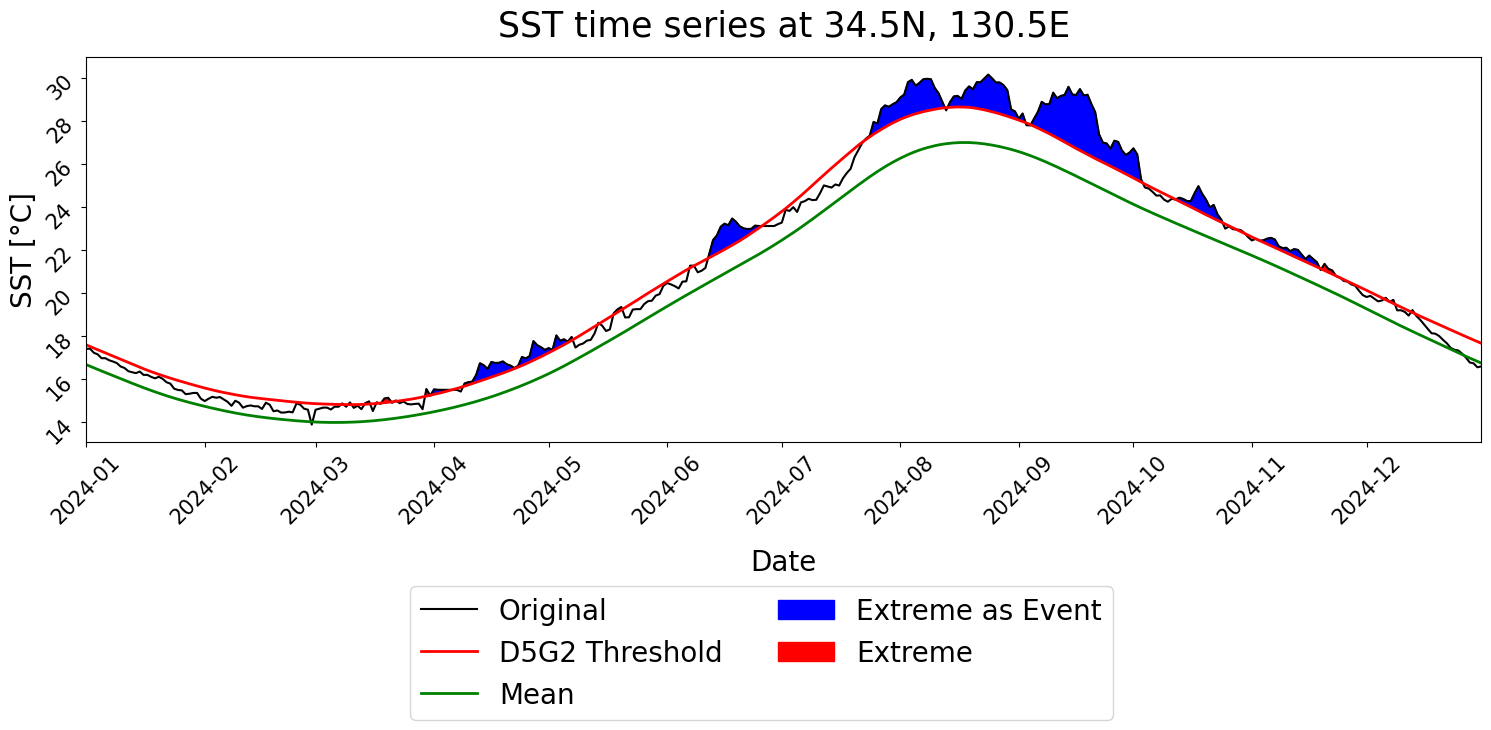

In [129]:
# --- Raw timeseries with extreme events
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(dates_selected, values_selected, 'k-', linewidth=1.5, label='Original')
ax.plot(dates_selected, thresh_selected, 'r-', linewidth=2, label=f'{crt} Threshold')
ax.plot(dates_selected, clim_selected, 'g-', linewidth=2, label='Mean')
ymin, ymax = ax.get_ylim()
ax.fill_between(
    df_selected['date'],
    df_selected['value'],
    df_selected['thresh'],
    where=(df_selected['value'] >= df_selected['thresh']) & (df_selected['event'] == 1),
    color='blue',
    interpolate=True,
    label='Extreme as Event'
)
ax.fill_between(
    df_selected['date'],
    df_selected['value'],
    df_selected['thresh'],
    where=(df_selected['value'] >= df_selected['thresh']) & (df_selected['event'] == 0),
    color='red',
    interpolate=True,
    label='Extreme'
)
ax.set_xlim(dates_selected.min(), dates_selected.max())
ax.set_ylim(ymin, ymax)  # y축 범위 다시 설정
ax.set_ylabel('TP [mm/day]' if varname0=='HR' else
              'SST [°C]' if varname0=='MHW' else
              'T2m [°C]',
              fontsize=20)
ax.set_xlabel('Date', fontsize=20, labelpad=15)
ax.tick_params(axis='both', which='major', labelsize=15, rotation=45)
ax.set_title(f"{varname.upper()} time series at {ly_}, {lx_}", fontsize=25, pad=15)
# ax.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     fontsize=18,
# )
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, fontsize=20)

plt.savefig(os.path.join(PATH_save_fig, f"{varname0}_daily_timeseries__{target_date_start}-{target_date_end}__p{thr}__{crt}.png"), dpi=100, bbox_inches='tight')
plt.show()

In [130]:
print('Saved to...........', os.path.join(PATH_save_fig, f"{varname0}_daily_timeseries__{target_date_start}-{target_date_end}__p{thr}__{crt}.png"))

Saved to........... /content/drive/MyDrive/APCC/figures/MHW_daily_timeseries__2024-01-01-2024-12-31__p90__D5G2.png


## **Visualization 2. Yearly timeseries with event sums**

Aggregate yearly event sums and calculate linear trend.

In [131]:
# --- Yearly timeseries for event sums
df['year'] = df['date'].dt.to_period('Y')
df_period = df[(df['year'] >= target_year_start) & (df['year'] <= target_year_end)].copy()
df_period.set_index('date', inplace=True)
yearly = df_period['event'].resample('Y').sum()

# Linear regression
years = np.array([d.year for d in yearly.index])
years_norm = years - years.min()
counts = yearly.values
slope, intercept, r_value, p_value, std_err = stats.linregress(years_norm, counts)
trend = intercept + slope * years_norm
eq = f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.3f}'

/tmp/ipykernel_2566/3811467370.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df_period['event'].resample('Y').sum()


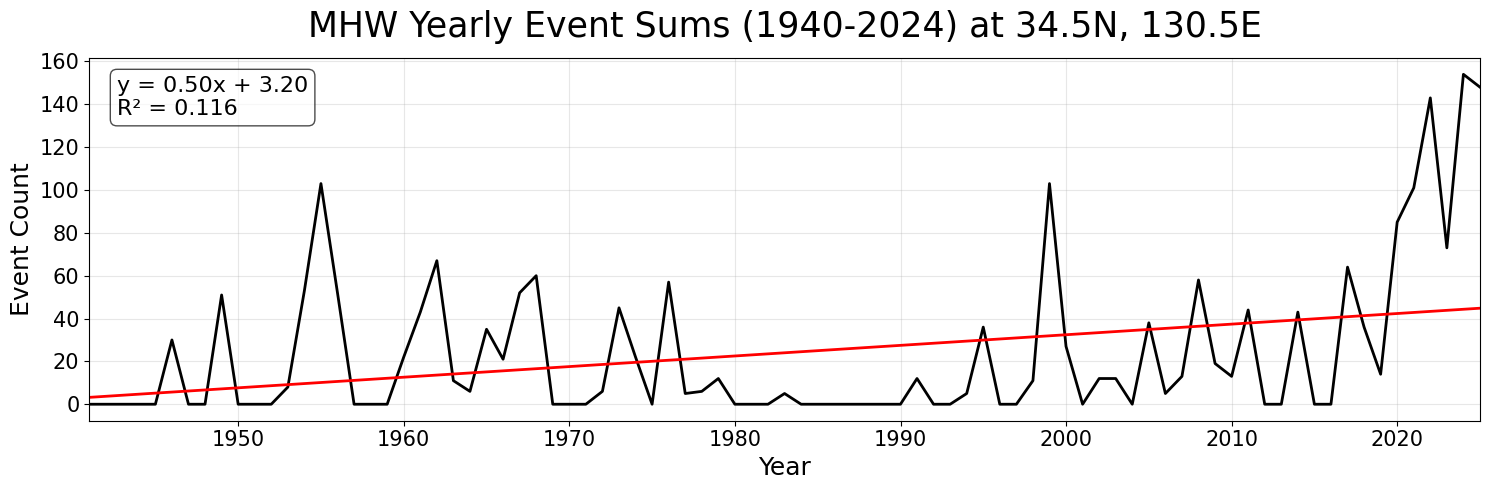

In [132]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(yearly.index, yearly.values, color='k', linewidth=2, label='Yearly Sum')
ax.plot(yearly.index, trend, 'r-', linewidth=2, label='Trend Line')
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Event Count', fontsize=18)
ax.set_title(f'{varname0} Yearly Event Sums ({target_year_start}-{target_year_end}) at {ly_}, {lx_}', fontsize=25, pad=15)
ax.tick_params(axis='both', which='major', labelsize=15)#, rotation=45)
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.text(0.02, 0.95, eq, transform=ax.transAxes,
        fontsize=16, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax.margins(x=0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PATH_save_fig, f"{varname0}_yearly_eventsums_timeseries__{target_year_start}-{target_year_end}__p{thr}__{crt}.png"), dpi=100, bbox_inches='tight')
plt.show()

In [133]:
print('Saved to...........', os.path.join(PATH_save_fig, f"{varname0}_yearly_eventsums_timeseries__{target_year_start}-{target_year_end}__p{thr}__{crt}.png"))

Saved to........... /content/drive/MyDrive/APCC/figures/MHW_yearly_eventsums_timeseries__1940-2024__p90__D5G2.png


## **Visualization 3. Monthly heatmap with event sums + Trend annotations**

In [134]:
# === Monthly Heatmap plot with event sums + trend annotations
# Ensure date and event columns
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Filter desired period
df_period = df[(df['year'] >= int(target_year_start)) & (df['year'] <= int(target_year_end))].copy()

# Group by year and month, summing events
monthly_sum = df_period.groupby(['year', 'month'])['event'].sum().reset_index()

# Pivot to wide format: rows=month, cols=year
heat_df = monthly_sum.pivot(index='month', columns='year', values='event')

# Compute trend (slope) for each month
slopes = {}
years = heat_df.columns.values
years_norm = years - years.min()
for month in heat_df.index:
    counts = heat_df.loc[month].values
    slope, _, _, p_value, _ = linregress(years_norm, counts)
    slopes[month] = slope

# Determine trend direction
trend_label = {m: '(+)' if slopes[m] > 0 else '(-)' if slopes[m] < 0 else '-' for m in heat_df.index}

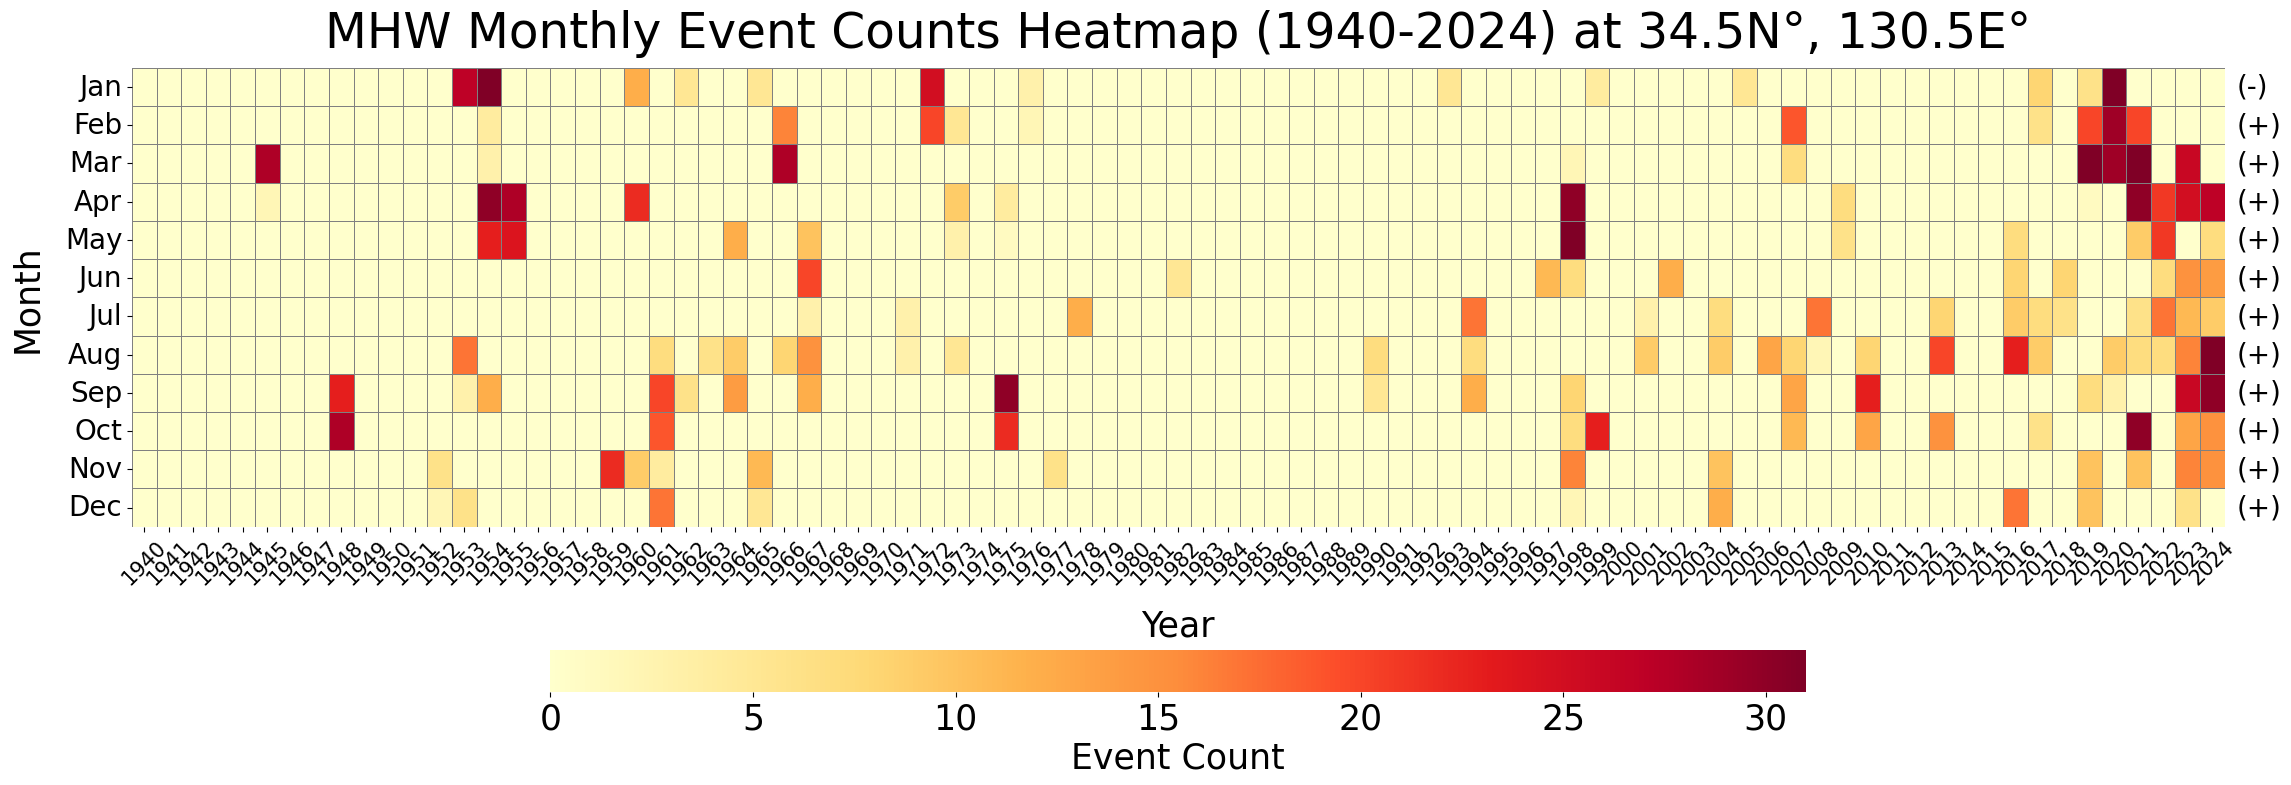

In [135]:
fig, ax = plt.subplots(figsize=(23, 8))
cbar_kws = {
    'label': 'Event Count',
    'orientation': 'horizontal',
    'pad': 0.18,           # Space between plot and colorbar
    'shrink': 0.6,         # Ratio of colorbar length
    'ticks': None,
    'aspect': 30
}
sns.heatmap(
    heat_df,
    cmap='YlOrRd',
    cbar_kws=cbar_kws,
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)   # colorbar tick fontsize
cbar.ax.xaxis.label.set_size(25)    # colorbar label fontsize
ax.set_xlabel('Year', fontsize=25, labelpad=15)
ax.set_ylabel('Month', fontsize=25, labelpad=15)
ax.set_title(f'{varname0} Monthly Event Counts Heatmap ({target_year_start}-{target_year_end}) at {ly_}°, {lx_}°', fontsize=35, pad=15)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(0.5, 12.5))
ax.set_yticklabels(months, rotation=0, fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=15)
for idx, month in enumerate(heat_df.index):
    ax.text(
        len(years) + 0.5,
        idx + 0.5,
        trend_label[month],
        va='center',
        ha='left',
        fontsize=20
    )
plt.subplots_adjust(right=0.9)
plt.tight_layout()

plt.savefig(os.path.join(PATH_save_fig, f"{varname0}_monthly_eventsums_heatmap__{target_year_start}-{target_year_end}__p{thr}__{crt}.png"), dpi=100, bbox_inches='tight')
plt.show()

In [136]:
print('Saved to...........', os.path.join(PATH_save_fig, f"{varname0}_monthly_eventsums_heatmap__{target_year_start}-{target_year_end}__p{thr}__{crt}.png"))

Saved to........... /content/drive/MyDrive/APCC/figures/MHW_monthly_eventsums_heatmap__1940-2024__p90__D5G2.png


## **Save statistics (NetCDF)**

0. Define Metadata & Units

In [137]:
if varname0 == 'HR':
    unit_val = 'mm/day'
    long_name_val = 'Heavy Rainfall'
elif varname0 == 'MHW':
    unit_val = 'degC'
    long_name_val = 'Marine HeatWaves'
else: # AHT
    unit_val = 'degC'
    long_name_val = 'Anomalously High Temperatures'

In [138]:
# Set global attributes
global_attrs = {
    'threshold_percentile': thr,
    'criteria': crt,
    'reference_period': f'{ref_syear}-{ref_eyear}'
}

In [139]:
print(global_attrs)

{'threshold_percentile': '90', 'criteria': 'D5G2', 'reference_period': '1991-2020'}


1. Daily Time Series Data (Visualization 1 Result)

In [140]:
ds_daily = df_selected.set_index('date').to_xarray()

ds_daily['value'].attrs = {'units': unit_val, 'long_name': f'Original {varname0} Value'}
ds_daily['thresh'].attrs = {'units': unit_val, 'long_name': f'{thr}th Percentile Threshold'}
ds_daily['clim'].attrs = {'units': unit_val, 'long_name': 'Climatological Mean'}
ds_daily['event'].attrs = {'units': 'binary', 'long_name': 'Extreme Event Flag (1=Event, 0=Non-event)'}
ds_daily.attrs = global_attrs.copy()
ds_daily.attrs['analysis_period'] = f'{target_date_start} to {target_date_end}'

In [141]:
print(ds_daily)

<xarray.Dataset> Size: 13kB
Dimensions:  (date: 366)
Coordinates:
  * date     (date) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
Data variables:
    value    (date) float32 1kB 17.41 17.41 17.22 17.15 ... 16.73 16.55 16.59
    thresh   (date) float64 3kB 17.59 17.51 17.44 17.36 ... 17.82 17.74 17.66
    clim     (date) float64 3kB 16.67 16.59 16.52 16.45 ... 16.9 16.82 16.75
    event    (date) int64 3kB 0 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
Attributes:
    threshold_percentile:  90
    criteria:              D5G2
    reference_period:      1991-2020
    analysis_period:       2024-01-01 to 2024-12-31


In [142]:
filename1 = os.path.join(PATH_save_stat, f"{varname0}_daily_timeseries__{target_date_start}-{target_date_end}__p{thr}__{crt}.nc")
ds_daily.to_netcdf(filename1)
print(f'Saved to............: {filename1}')

Saved to............: /content/drive/MyDrive/APCC/statistics/MHW_daily_timeseries__2024-01-01-2024-12-31__p90__D5G2.nc


2. Yearly Event Sums (Visualization 2 Result)

In [143]:
ds_yearly = yearly.to_xarray().to_dataset(name='event_count')

ds_yearly['event_count'].attrs = {'units': 'days', 'long_name': 'Yearly Event Sums'}
ds_yearly.attrs['trend_slope'] = float(slope)
ds_yearly.attrs['trend_intercept'] = float(intercept)
ds_yearly.attrs['trend_r2'] = float(r_value**2)
ds_daily.attrs = global_attrs.copy()
ds_daily.attrs['analysis_period'] = f'{target_year_start} to {target_year_end}'

In [144]:
print(ds_yearly)

<xarray.Dataset> Size: 1kB
Dimensions:      (date: 85)
Coordinates:
  * date         (date) datetime64[ns] 680B 1940-12-31 1941-12-31 ... 2024-12-31
Data variables:
    event_count  (date) int64 680B 0 0 0 0 0 30 0 0 ... 14 85 101 143 73 154 148
Attributes:
    trend_slope:      0.015907758452218097
    trend_intercept:  3.201367989056095
    trend_r2:         0.11568465903928833


In [145]:
filename2 = os.path.join(PATH_save_stat, f"{varname0}_yearly_eventsums_timeseries__{target_year_start}-{target_year_end}__p{thr}__{crt}.nc")
ds_yearly.to_netcdf(filename2)
print(f'Saved to............: {filename2}')

Saved to............: /content/drive/MyDrive/APCC/statistics/MHW_yearly_eventsums_timeseries__1940-2024__p90__D5G2.nc


3. Monthly Heatmap Data (Visualization 3 Result)

In [146]:
ds_monthly = monthly_sum.set_index(['year', 'month']).to_xarray()

ds_monthly['event'].attrs = {'units': 'days', 'long_name': 'Monthly Event Counts'}
ds_monthly.attrs = global_attrs.copy()
ds_daily.attrs['analysis_period'] = f'{target_year_start} to {target_year_end}'

In [147]:
print(ds_monthly)

<xarray.Dataset> Size: 9kB
Dimensions:  (year: 85, month: 12)
Coordinates:
  * year     (year) int32 340B 1940 1941 1942 1943 1944 ... 2021 2022 2023 2024
  * month    (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    event    (year, month) int64 8kB 0 0 0 0 0 0 0 0 0 ... 7 14 9 31 30 15 15 0
Attributes:
    threshold_percentile:  90
    criteria:              D5G2
    reference_period:      1991-2020


In [148]:
filename3 = os.path.join(PATH_save_stat, f"{varname0}_monthly_eventsums_heatmap__{target_year_start}-{target_year_end}__p{thr}__{crt}.nc")
ds_monthly.to_netcdf(filename3)
print(f'Saved to............: {filename3}')

Saved to............: /content/drive/MyDrive/APCC/statistics/MHW_monthly_eventsums_heatmap__1940-2024__p90__D5G2.nc
